In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

La Obesidad en mexico es un problema serio que afecta la calidad de vida de una gran parte de la poblacion en mexico, se tiene el estigma de que en gran parte se debe a la falta de diciplina y voluntad de las personas para tener habitos saludables, pero esto es cierto? que dicen los datos al respecto?

# La obesidad en México

La obesidad en México es un problema serio que afecta la calidad de vida de una gran parte de la población. 

Existe un estigma que sugiere que, en gran medida, se debe a la falta de disciplina y voluntad de las personas para mantener hábitos saludables. 

Pero, ¿esto es realmente cierto?  
¿Qué dicen los datos al respecto?

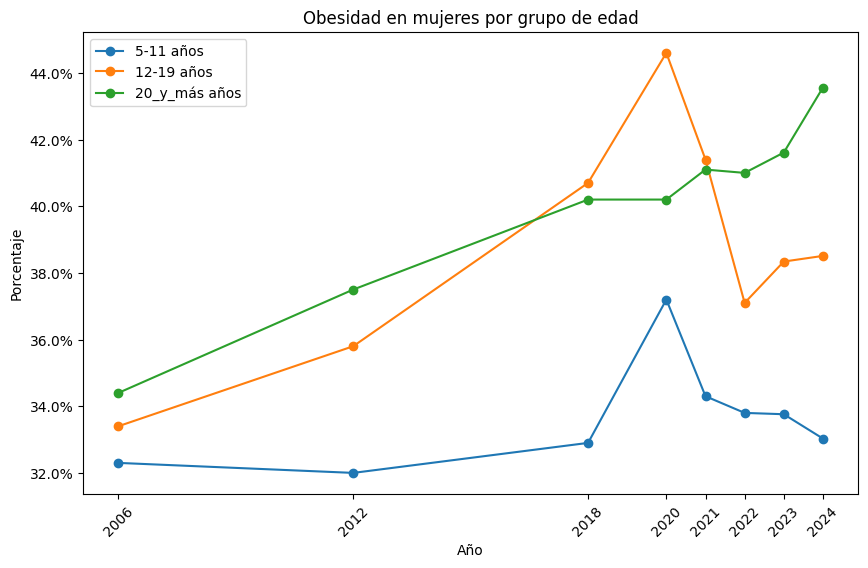

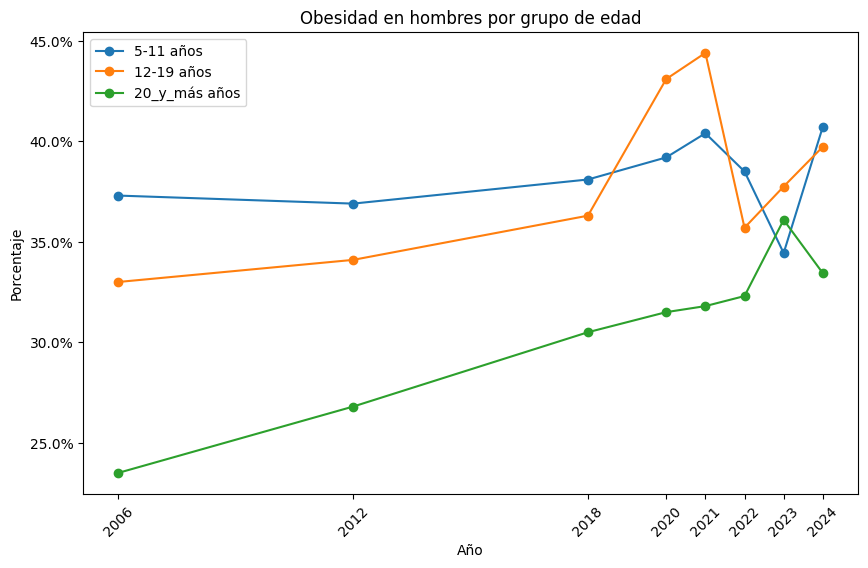

In [2]:
# Cargar datos
df = pd.read_csv('conjunto_de_datos/3n.4.1a_sh_esUSAR.csv')

# Asegurar orden temporal
df = df.sort_values(by='Periodo')

# Extraer columnas por grupo
edades = ['5-11', '12-19', '20_y_más']

# Crear subconjuntos
df_mujeres = df[[f'Población_con_sobrepeso_y_obesidad|{edad}_años_mujeres' for edad in edades] + ['Periodo']]
df_hombres = df[[f'Población_con_sobrepeso_y_obesidad|{edad}_años_hombres' for edad in edades] + ['Periodo']]

# -----------------------
# GRÁFICA MUJERES
# -----------------------
plt.figure(figsize=(10,6))

for edad in edades:
    plt.plot(
        df_mujeres['Periodo'],
        df_mujeres[f'Población_con_sobrepeso_y_obesidad|{edad}_años_mujeres'],
        marker='o',
        label=f'{edad} años'
    )

plt.title('Obesidad en mujeres por grupo de edad')
plt.xlabel('Año')
plt.ylabel('Porcentaje')
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.xticks(df_mujeres['Periodo'], rotation=45)
plt.legend()


plt.show()

# -----------------------
# GRÁFICA HOMBRES
# -----------------------
plt.figure(figsize=(10,6))

for edad in edades:
    plt.plot(
        df_hombres['Periodo'],
        df_hombres[f'Población_con_sobrepeso_y_obesidad|{edad}_años_hombres'],
        marker='o',
        label=f'{edad} años'
    )

plt.title('Obesidad en hombres por grupo de edad')
plt.xlabel('Año')
plt.ylabel('Porcentaje')
plt.gca().yaxis.set_major_formatter(PercentFormatter())
plt.xticks(df_hombres['Periodo'], rotation=45)
plt.legend()


plt.show()

## Interpretación de los resultados

Estas gráficas muestran cómo ha ido aumentando el porcentaje de obesidad en México en hombres y mujeres de distintos rangos de edad. 

Se observa un cambio más brusco en el periodo correspondiente a la pandemia. Esto plantea varias preguntas: ¿será que la población modificó significativamente sus hábitos durante este periodo?

Pero más allá de una explicación individual, surge otra cuestión:  
¿los mexicanos se están volviendo más flojos y descuidados, o estamos desarrollando un país que estructuralmente fomenta estos cambios?

En este sentido, cabe preguntarse si la obesidad podría entenderse no solo como una condición individual, sino como una patología derivada de un desarrollo estructural deficiente.

## Análisis del tiempo disponible y su uso en la vida cotidiana

Analicemos el tiempo disponible del ciudadano promedio y cómo influye la sociedad en el uso del mismo. 

A continuación, se muestran algunas gráficas que nos permiten visualizar el tiempo promedio que se destina a los traslados al trabajo, medido en horas por semana.

✅ Generando gráficas de HORAS para el periodo: 2024


/tmp/ipykernel_52175/3603678015.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=horas_hombres.index, y=horas_hombres.values, ax=axes[0], palette=color_h)
/tmp/ipykernel_52175/3603678015.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=horas_mujeres.index, y=horas_mujeres.values, ax=axes[1], palette=color_m)


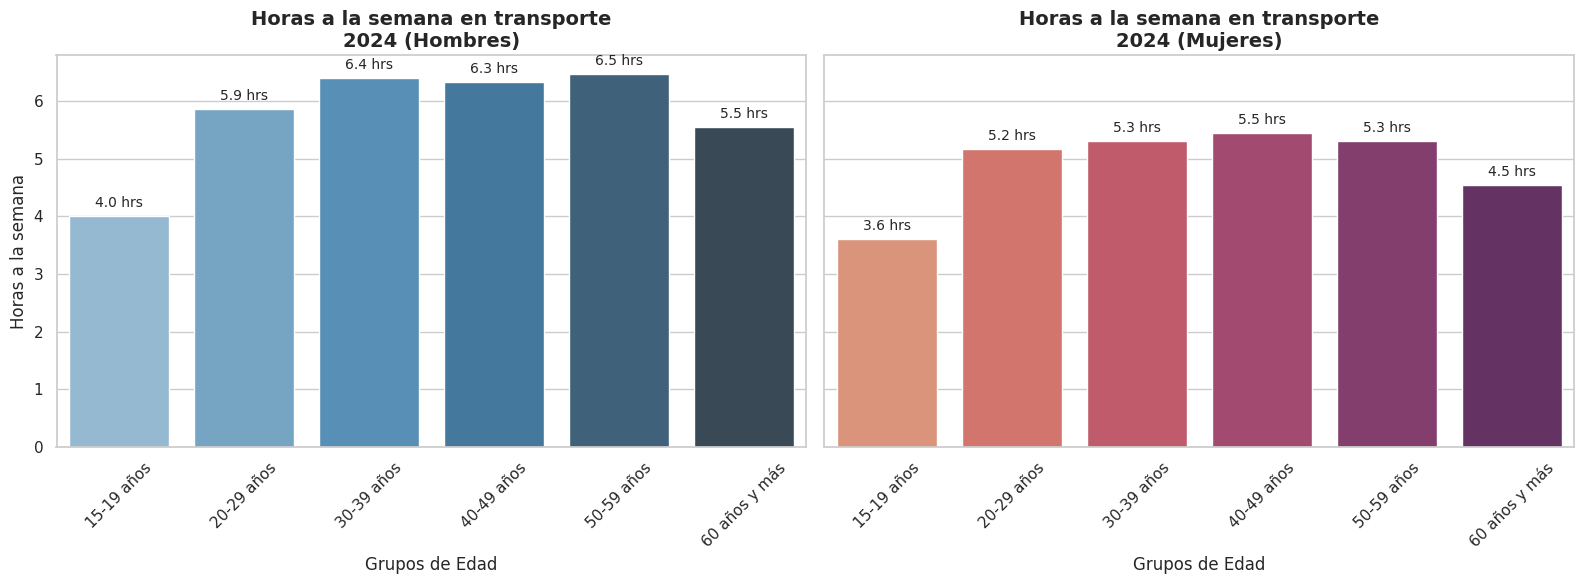

In [3]:
Tiempor_traslado2 = pd.read_csv('conjunto_de_datos/11r.2.1d_sh_es.csv')
# 1. Usamos tu DataFrame con los promedios correctos
df_promedios = Tiempor_traslado2.copy()

# Encontrar el periodo más reciente automáticamente
ultimo_periodo = df_promedios['Periodo'].dropna().sort_values().iloc[-1]
print(f"✅ Generando gráficas de HORAS para el periodo: {ultimo_periodo}")

df_reciente = df_promedios[df_promedios['Periodo'] == ultimo_periodo].copy()

if 'Unnamed: 20' in df_reciente.columns:
    df_reciente = df_reciente.drop(columns=['Unnamed: 20'])

# 2. Separar las columnas por sexo
cols_hombres = [col for col in df_reciente.columns if 'Hombres' in col]
cols_mujeres = [col for col in df_reciente.columns if 'Mujeres' in col]

# 3. Limpieza de formato (comas a puntos para decimales)
for col in cols_hombres + cols_mujeres:
    if df_reciente[col].dtype == 'object':
        df_reciente[col] = df_reciente[col].astype(str).str.replace(',', '.')
    df_reciente[col] = pd.to_numeric(df_reciente[col], errors='coerce')

# 4. Extraer los promedios
datos_hombres = df_reciente[cols_hombres].mean()
datos_mujeres = df_reciente[cols_mujeres].mean()

# 5. EL NUEVO CÁLCULO: Convertir de minutos a horas a la semana
horas_hombres = datos_hombres / 60
horas_mujeres = datos_mujeres / 60

# Limpiar el texto del eje X para que solo diga la edad
def extraer_edad(nombre_columna):
    return str(nombre_columna).split('|')[-1].replace('_', ' ')

horas_hombres.index = horas_hombres.index.map(extraer_edad)
horas_mujeres.index = horas_mujeres.index.map(extraer_edad)

# 6. Visualización
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

color_h = sns.color_palette("Blues_d", len(horas_hombres))
color_m = sns.color_palette("flare", len(horas_mujeres))

# --- Gráfica Hombres ---
sns.barplot(x=horas_hombres.index, y=horas_hombres.values, ax=axes[0], palette=color_h)
axes[0].set_title(f'Horas a la semana en transporte\n{ultimo_periodo} (Hombres)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grupos de Edad', fontsize=12)
axes[0].set_ylabel('Horas a la semana', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Etiquetas con "hrs"
for i, v in enumerate(horas_hombres.values):
    if not np.isnan(v):
        axes[0].text(i, v + 0.1, f'{v:.1f} hrs', ha='center', va='bottom', fontsize=10)

# --- Gráfica Mujeres ---
sns.barplot(x=horas_mujeres.index, y=horas_mujeres.values, ax=axes[1], palette=color_m)
axes[1].set_title(f'Horas a la semana en transporte\n{ultimo_periodo} (Mujeres)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grupos de Edad', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Etiquetas con "hrs"
for i, v in enumerate(horas_mujeres.values):
    if not np.isnan(v):
        axes[1].text(i, v + 0.1, f'{v:.1f} hrs', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Contexto: tiempo laboral en México

Según datos del INEGI, las mujeres dedican en promedio 61.1 horas semanales al tiempo total de trabajo, mientras que los hombres dedican 58.0 horas. Además, una gran proporción de este tiempo corresponde a actividades no remuneradas, representando el 66.8 % en mujeres y el 33.2 % en hombres.

Sumado a esto, también se menciona que dormir ocho horas contribuye a evitar enfermedades crónico-degenerativas. Suponiendo, de manera sumamente optimista, que el mexicano promedio tuviera el privilegio de dormir 8 horas diarias, tendríamos la siguiente gestión del tiempo semanal.

Para este análisis, nos enfocaremos en los grupos de edad entre 20 y 49 años.

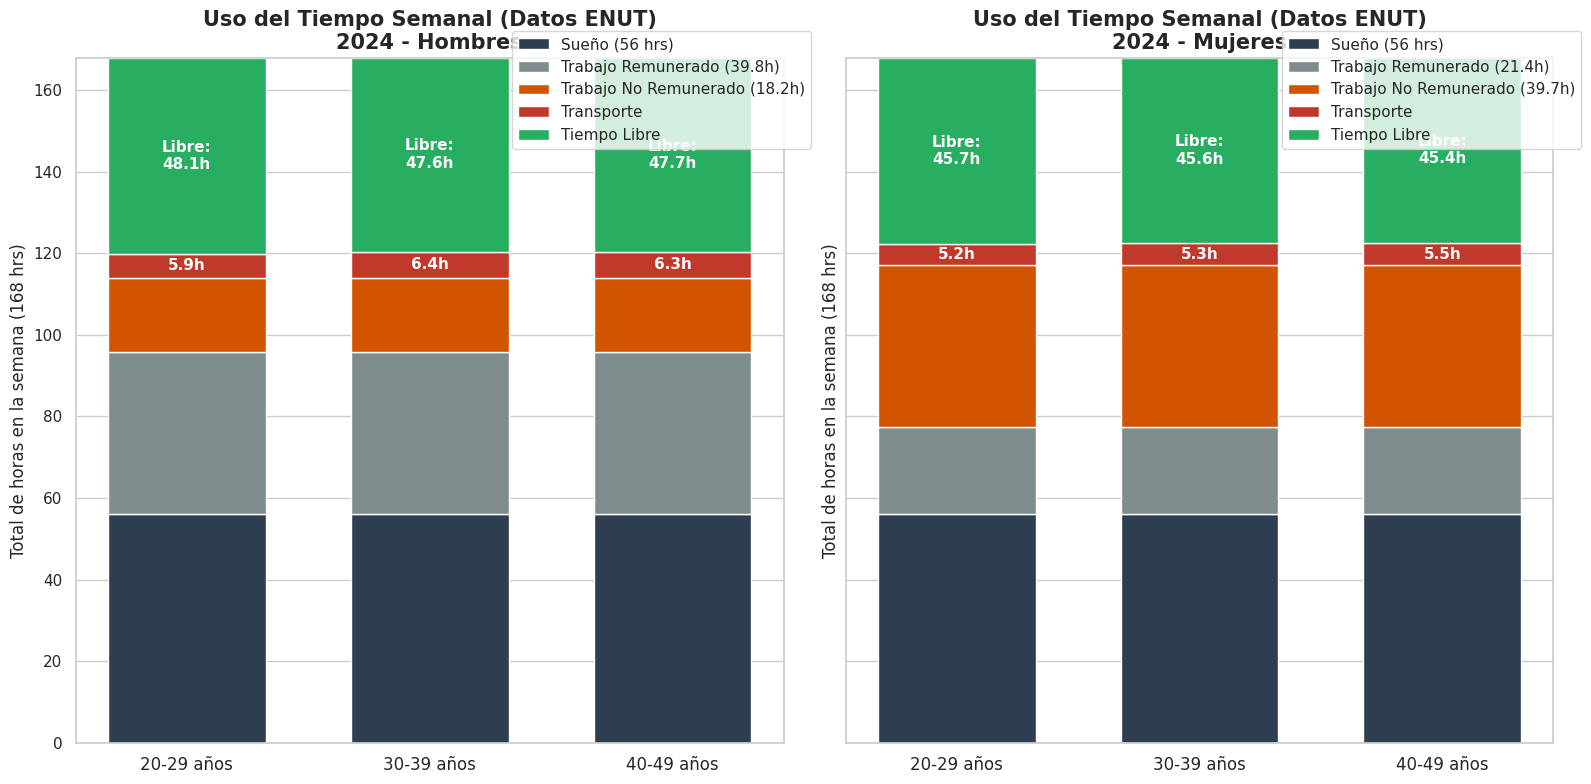

In [4]:


# 1. Preparar los datos de transporte
df_promedios = Tiempor_traslado2.copy()
ultimo_periodo = df_promedios['Periodo'].dropna().sort_values().iloc[-1]

df_reciente = df_promedios[df_promedios['Periodo'] == ultimo_periodo].copy()

cols_hombres = [col for col in df_reciente.columns if 'Hombres' in col]
cols_mujeres = [col for col in df_reciente.columns if 'Mujeres' in col]

for col in cols_hombres + cols_mujeres:
    if df_reciente[col].dtype == 'object':
        df_reciente[col] = df_reciente[col].astype(str).str.replace(',', '.')
    df_reciente[col] = pd.to_numeric(df_reciente[col], errors='coerce')

horas_hombres = df_reciente[cols_hombres].mean() / 60
horas_mujeres = df_reciente[cols_mujeres].mean() / 60

def extraer_edad(nombre_columna):
    return str(nombre_columna).split('|')[-1].replace('_', ' ')

horas_hombres.index = horas_hombres.index.map(extraer_edad)
horas_mujeres.index = horas_mujeres.index.map(extraer_edad)

grupos_objetivo = ['20-29 años', '30-39 años', '40-49 años']
horas_hombres = horas_hombres[horas_hombres.index.isin(grupos_objetivo)]
horas_mujeres = horas_mujeres[horas_mujeres.index.isin(grupos_objetivo)]

# 2. NUEVA DISTRIBUCIÓN BASADA EN DATOS ENUT (INEGI)
horas_semana = 168
horas_sueno = 56    # 8 horas * 7 días

# Tiempos de trabajo Hombres (Total: 58.0 hrs)
horas_trabajo_no_remunerado_h = 18.2
horas_trabajo_remunerado_h = 58.0 - 18.2 # 39.8 hrs

# Tiempos de trabajo Mujeres (Total: 61.1 hrs)
horas_trabajo_no_remunerado_m = 39.7
horas_trabajo_remunerado_m = 61.1 - 39.7 # 21.4 hrs

# Calcular el "Tiempo Libre" restante real
tiempo_libre_hombres = horas_semana - (horas_sueno + 58.0 + horas_hombres)
tiempo_libre_mujeres = horas_semana - (horas_sueno + 61.1 + horas_mujeres)

# 3. Configuración visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
x = np.arange(len(grupos_objetivo))
width = 0.65

# Nueva paleta de colores para diferenciar los tipos de trabajo
color_sueno = '#2c3e50'                 # Azul oscuro
color_trabajo_remunerado = '#7f8c8d'    # Gris
color_trabajo_no_remunerado = '#d35400' # Naranja (El factor de desigualdad)
color_transporte = '#c0392b'            # Rojo
color_libre = '#27ae60'                 # Verde

# --- Función auxiliar para apilar y etiquetar ---
def graficar_semana_enut(ax, datos_transporte, datos_libre, hrs_remunerado, hrs_no_remunerado, titulo):
    hrs_trabajo_total = hrs_remunerado + hrs_no_remunerado

    # Bases para apilar las barras
    bottom_remunerado = [horas_sueno] * len(grupos_objetivo)
    bottom_no_remunerado = [horas_sueno + hrs_remunerado] * len(grupos_objetivo)
    bottom_transporte = [horas_sueno + hrs_trabajo_total] * len(grupos_objetivo)
    bottom_libre = bottom_transporte + datos_transporte.values

    # Dibujar barras
    ax.bar(x, [horas_sueno]*len(grupos_objetivo), width, label='Sueño (56 hrs)', color=color_sueno)
    ax.bar(x, [hrs_remunerado]*len(grupos_objetivo), width, bottom=bottom_remunerado, label=f'Trabajo Remunerado ({hrs_remunerado:.1f}h)', color=color_trabajo_remunerado)
    ax.bar(x, [hrs_no_remunerado]*len(grupos_objetivo), width, bottom=bottom_no_remunerado, label=f'Trabajo No Remunerado ({hrs_no_remunerado:.1f}h)', color=color_trabajo_no_remunerado)
    ax.bar(x, datos_transporte.values, width, bottom=bottom_transporte, label='Transporte', color=color_transporte)
    ax.bar(x, datos_libre.values, width, bottom=bottom_libre, label='Tiempo Libre', color=color_libre)

    # Formato
    ax.set_title(titulo, fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(grupos_objetivo, fontsize=12)
    ax.set_ylabel('Total de horas en la semana (168 hrs)', fontsize=12)
    ax.set_ylim(0, 168)
    
    # Mover la leyenda afuera para que no tape los datos
    ax.legend(loc='upper right', bbox_to_anchor=(1.05, 1.05))

    # Agregar etiquetas clave (Transporte y Tiempo Libre)
    for i in range(len(grupos_objetivo)):
        val_transporte = datos_transporte.values[i]
        val_libre = datos_libre.values[i]
        
        # Etiqueta Transporte
        y_transporte = bottom_transporte[i] + (val_transporte / 2)
        ax.text(i, y_transporte, f'{val_transporte:.1f}h', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        
        # Etiqueta Tiempo Libre (El verdadero tiempo sobrante)
        y_libre = bottom_libre[i] + (val_libre / 2)
        ax.text(i, y_libre, f'Libre:\n{val_libre:.1f}h', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# --- Dibujar ambas gráficas ---
graficar_semana_enut(axes[0], horas_hombres, tiempo_libre_hombres, horas_trabajo_remunerado_h, horas_trabajo_no_remunerado_h, f'Uso del Tiempo Semanal (Datos ENUT)\n{ultimo_periodo} - Hombres')
graficar_semana_enut(axes[1], horas_mujeres, tiempo_libre_mujeres, horas_trabajo_remunerado_m, horas_trabajo_no_remunerado_m, f'Uso del Tiempo Semanal (Datos ENUT)\n{ultimo_periodo} - Mujeres')

plt.tight_layout()
plt.show()

## Ajuste del tiempo disponible entre semana

Ahora, a este cálculo es necesario restarle las horas correspondientes al fin de semana, así como las horas de sueño durante esos días, con el objetivo de centrarnos únicamente en el tiempo disponible entre semana.

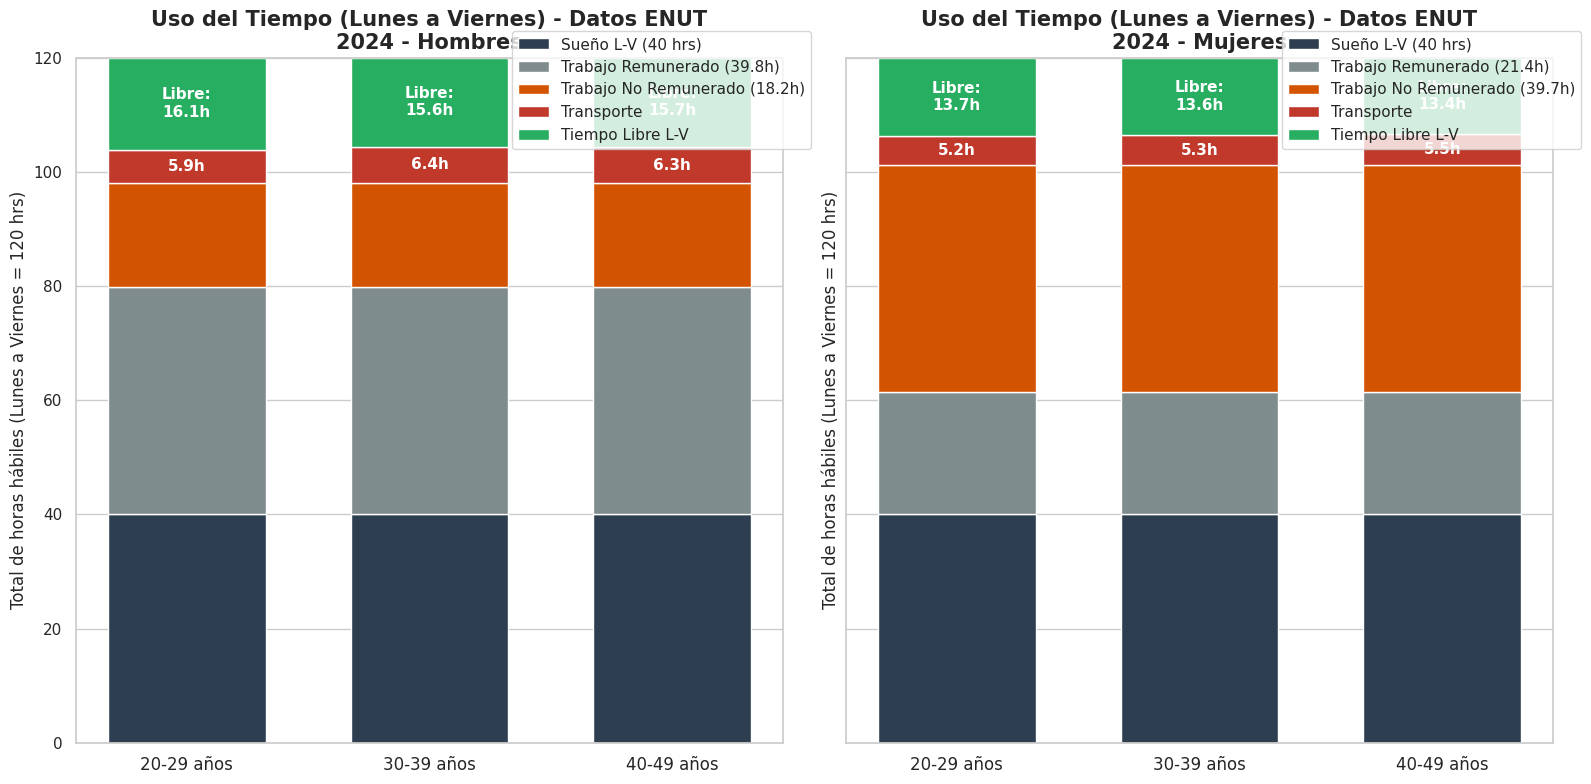

In [5]:
# 1. Preparar los datos de transporte
df_promedios = Tiempor_traslado2.copy()
ultimo_periodo = df_promedios['Periodo'].dropna().sort_values().iloc[-1]

df_reciente = df_promedios[df_promedios['Periodo'] == ultimo_periodo].copy()

cols_hombres = [col for col in df_reciente.columns if 'Hombres' in col]
cols_mujeres = [col for col in df_reciente.columns if 'Mujeres' in col]

for col in cols_hombres + cols_mujeres:
    if df_reciente[col].dtype == 'object':
        df_reciente[col] = df_reciente[col].astype(str).str.replace(',', '.')
    df_reciente[col] = pd.to_numeric(df_reciente[col], errors='coerce')

horas_hombres = df_reciente[cols_hombres].mean() / 60
horas_mujeres = df_reciente[cols_mujeres].mean() / 60

def extraer_edad(nombre_columna):
    return str(nombre_columna).split('|')[-1].replace('_', ' ')

horas_hombres.index = horas_hombres.index.map(extraer_edad)
horas_mujeres.index = horas_mujeres.index.map(extraer_edad)

grupos_objetivo = ['20-29 años', '30-39 años', '40-49 años']
horas_hombres = horas_hombres[horas_hombres.index.isin(grupos_objetivo)]
horas_mujeres = horas_mujeres[horas_mujeres.index.isin(grupos_objetivo)]

# 2. NUEVA DISTRIBUCIÓN: SEMANA HÁBIL (Lunes a Viernes)
horas_semana_habil = 120  # 5 días * 24 horas
horas_sueno_habil = 40    # 5 días * 8 horas

# Tiempos de trabajo Hombres (Total: 58.0 hrs)
# Asumimos que la mayor carga laboral de la semana recae en estos 5 días
horas_trabajo_no_remunerado_h = 18.2
horas_trabajo_remunerado_h = 39.8

# Tiempos de trabajo Mujeres (Total: 61.1 hrs)
horas_trabajo_no_remunerado_m = 39.7
horas_trabajo_remunerado_m = 21.4

# Calcular el "Tiempo Libre" restante real (Lunes a Viernes)
tiempo_libre_hombres = horas_semana_habil - (horas_sueno_habil + 58.0 + horas_hombres)
tiempo_libre_mujeres = horas_semana_habil - (horas_sueno_habil + 61.1 + horas_mujeres)

# 3. Configuración visual
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
x = np.arange(len(grupos_objetivo))
width = 0.65

# Paleta de colores 
color_sueno = '#2c3e50'                 # Azul oscuro
color_trabajo_remunerado = '#7f8c8d'    # Gris
color_trabajo_no_remunerado = '#d35400' # Naranja 
color_transporte = '#c0392b'            # Rojo
color_libre = '#27ae60'                 # Verde

# --- Función auxiliar para apilar y etiquetar ---
def graficar_semana_habil(ax, datos_transporte, datos_libre, hrs_remunerado, hrs_no_remunerado, titulo):
    hrs_trabajo_total = hrs_remunerado + hrs_no_remunerado

    # Bases para apilar las barras
    bottom_remunerado = [horas_sueno_habil] * len(grupos_objetivo)
    bottom_no_remunerado = [horas_sueno_habil + hrs_remunerado] * len(grupos_objetivo)
    bottom_transporte = [horas_sueno_habil + hrs_trabajo_total] * len(grupos_objetivo)
    bottom_libre = bottom_transporte + datos_transporte.values

    # Dibujar barras
    ax.bar(x, [horas_sueno_habil]*len(grupos_objetivo), width, label='Sueño L-V (40 hrs)', color=color_sueno)
    ax.bar(x, [hrs_remunerado]*len(grupos_objetivo), width, bottom=bottom_remunerado, label=f'Trabajo Remunerado ({hrs_remunerado:.1f}h)', color=color_trabajo_remunerado)
    ax.bar(x, [hrs_no_remunerado]*len(grupos_objetivo), width, bottom=bottom_no_remunerado, label=f'Trabajo No Remunerado ({hrs_no_remunerado:.1f}h)', color=color_trabajo_no_remunerado)
    ax.bar(x, datos_transporte.values, width, bottom=bottom_transporte, label='Transporte', color=color_transporte)
    ax.bar(x, datos_libre.values, width, bottom=bottom_libre, label='Tiempo Libre L-V', color=color_libre)

    # Formato
    ax.set_title(titulo, fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(grupos_objetivo, fontsize=12)
    ax.set_ylabel('Total de horas hábiles (Lunes a Viernes = 120 hrs)', fontsize=12)
    ax.set_ylim(0, 120) # Ajustado al límite de 120 horas
    
    # Mover la leyenda afuera 
    ax.legend(loc='upper right', bbox_to_anchor=(1.05, 1.05))

    # Agregar etiquetas clave (Transporte y Tiempo Libre)
    for i in range(len(grupos_objetivo)):
        val_transporte = datos_transporte.values[i]
        val_libre = datos_libre.values[i]
        
        # Etiqueta Transporte
        y_transporte = bottom_transporte[i] + (val_transporte / 2)
        ax.text(i, y_transporte, f'{val_transporte:.1f}h', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        
        # Etiqueta Tiempo Libre 
        y_libre = bottom_libre[i] + (val_libre / 2)
        ax.text(i, y_libre, f'Libre:\n{val_libre:.1f}h', ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# --- Dibujar ambas gráficas ---
graficar_semana_habil(axes[0], horas_hombres, tiempo_libre_hombres, horas_trabajo_remunerado_h, horas_trabajo_no_remunerado_h, f'Uso del Tiempo (Lunes a Viernes) - Datos ENUT\n{ultimo_periodo} - Hombres')
graficar_semana_habil(axes[1], horas_mujeres, tiempo_libre_mujeres, horas_trabajo_remunerado_m, horas_trabajo_no_remunerado_m, f'Uso del Tiempo (Lunes a Viernes) - Datos ENUT\n{ultimo_periodo} - Mujeres')

plt.tight_layout()
plt.show()

## Reflexión sobre el tiempo disponible

Esto nos deja aproximadamente 3 horas —o incluso menos— libres al día. Y esto considerando únicamente tres variables: sueño, trabajo y transporte.

¿Son realmente suficientes tres horas para cubrir el resto de las actividades del día, incluyendo el ejercicio y la construcción de hábitos saludables?

¿Es simplemente una cuestión de disciplina, o es un ideal poco realista pensar que, después de jornadas largas de trabajo y traslados, aún se cuenta con la energía necesaria para optimizar ese tiempo en todas las actividades restantes?

Esta reflexión abre la puerta a cuestionar si el problema es verdaderamente individual, o si existe un componente estructural que condiciona la forma en la que las personas pueden gestionar su tiempo.

## Referencias y Fuentes de Datos

Para el desarrollo de este análisis de Pobreza de Tiempo y su impacto en la salud de la población mexicana, se consultaron y procesaron las siguientes fuentes oficiales:

### Artículos y Comunicados Oficiales
* **INEGI (2025).** *Encuesta Nacional sobre Uso del Tiempo (ENUT) - Comunicado de Prensa 121/25*. Instituto Nacional de Estadística y Geografía. Disponible en: [Boletín ENUT 2024 (PDF)](https://www.inegi.org.mx/contenidos/saladeprensa/boletines/2025/enut/enut2024_CP.pdf)
* **Secretaría de Salud.** *Ocho horas de sueño contribuyen a evitar enfermedades crónico-degenerativas*. Gobierno de México. Disponible en: [Comunicado de Prensa de la Secretaría de Salud](https://www.gob.mx/salud/prensa/ocho-horas-de-sueno-contribuyen-a-evitar-enfermedades-cronico-degenerativas)

### Bases de Datos Utilizadas

**1. Encuesta Nacional sobre Uso del Tiempo (ENUT)**
* **Institución Generadora:** Instituto Nacional de Estadística y Geografía (INEGI).
* **Descripción de los datos:** Esta base proporciona información clave sobre el indicador de "Tiempo promedio de traslado al trabajo". Mide los minutos semanales que la población de 15 años y más invierte en sus desplazamientos laborales. Además, desglosa el tiempo total de trabajo semanal en actividades remuneradas y no remuneradas (trabajo doméstico y de cuidados), evidenciando una brecha de género significativa.
* **Cobertura temporal analizada:** 2014 - 2024 (Datos actualizados al 03 de febrero de 2026).
* **Enlace de consulta:** [Programa ENUT - INEGI](https://www.inegi.org.mx/programas/enut/)

**2. Encuesta Nacional de Salud y Nutrición (ENSANUT)**
* **Institución Generadora:** Instituto Nacional de Salud Pública (INSP) / Secretaría de Salud.
* **Descripción de los datos:** Base de datos utilizada para cruzar el impacto de la pobreza de tiempo con la salud pública. Contiene el porcentaje de la población con sobrepeso y obesidad, clasificado mediante el Índice de Masa Corporal (IMC) y desglosado por sexo y grupos de edad. La ficha técnica de esta base resalta que estas condiciones representan un costo creciente para el sistema de salud e incrementan el riesgo de mortalidad prematura.
* **Cobertura temporal analizada:** 2006 - 2024 (Datos actualizados al 17 de marzo de 2026).
* **Enlace de consulta:** [Plataforma ENSANUT - INSP](https://ensanut.insp.mx/)